<a href="https://colab.research.google.com/github/rajakchhavi1-prog/Credit-Risk-Modelling/blob/main/credit_risk_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import  train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


In [ ]:
df = pd.read_csv('/content/sample_data/corporate_credit_risk_dataset.csv')
df.head()

,Firm_ID,Sector,Total_Assets,Total_Liabilities,Revenue,EBIT,Interest_Expense,Current_Ratio,Debt_to_Equity,ROA,Interest_Coverage,Leverage_Ratio,Default
0,FIRM_1,Infrastructure,585.034111,581.037024,341.381322,39.825316,35.211721,0.885600,1.731275,0.062527,1.131024,0.993168,1
1,FIRM_2,Retail,475.324935,167.777424,603.689893,-8.544587,33.482801,1.606372,1.673480,0.112415,-0.255193,0.352974,1
2,FIRM_3,Pharma,478.551360,493.415132,452.023136,45.313817,12.669939,0.717164,1.247400,0.035820,3.576483,1.031060,0
3,FIRM_4,Retail,209.814471,202.445334,383.424294,78.676690,12.567100,2.148877,1.847726,0.058048,6.260529,0.964878,0
4,FIRM_5,Retail,522.598857,367.227085,368.499174,45.710981,14.071721,2.771834,2.055562,0.074739,3.248429,0.702694,0


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Firm_ID            300 non-null    object 
 1   Sector             300 non-null    object 
 2   Total_Assets       300 non-null    float64
 3   Total_Liabilities  300 non-null    float64
 4   Revenue            300 non-null    float64
 5   EBIT               300 non-null    float64
 6   Interest_Expense   300 non-null    float64
 7   Current_Ratio      300 non-null    float64
 8   Debt_to_Equity     300 non-null    float64
 9   ROA                300 non-null    float64
 10  Interest_Coverage  300 non-null    float64
 11  Leverage_Ratio     300 non-null    float64
 12  Default            300 non-null    int64  
dtypes: float64(10), int64(1), object(2)
memory usage: 30.6+ KB


,0
Firm_ID,0
Sector,0
Total_Assets,0
Total_Liabilities,0
Revenue,0
EBIT,0
Interest_Expense,0
Current_Ratio,0
Debt_to_Equity,0
ROA,0


In [ ]:
df["Default"].value_counts(normalize=True)

,proportion
Default,
0,0.7
1,0.3


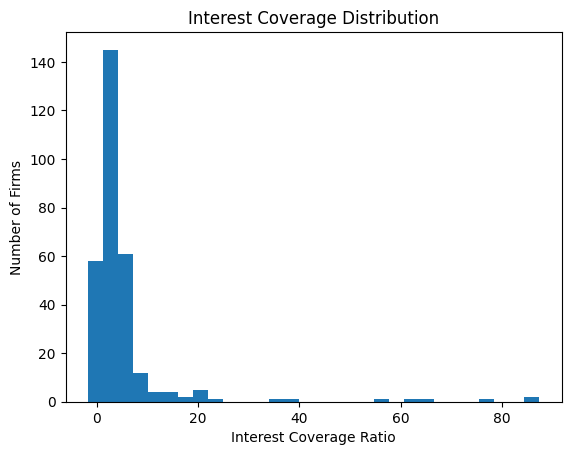

In [ ]:
plt.hist(df["Interest_Coverage"], bins=30)
plt.title("Interest Coverage Distribution")
plt.xlabel("Interest Coverage Ratio")
plt.ylabel("Number of Firms")
plt.show()

In [ ]:
features = [
    "Leverage_Ratio",
    "Debt_to_Equity",
    "Current_Ratio",
    "ROA",
    "Interest_Coverage"
]

x = df[features]
y = df["Default"]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

In [ ]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.87      1.00      0.93        61
           1       1.00      0.69      0.82        29

    accuracy                           0.90        90
   macro avg       0.94      0.84      0.87        90
weighted avg       0.91      0.90      0.89        90



In [ ]:
roc_auc_score(y_test, y_prob)

np.float64(0.9429055963821368)

In [ ]:
confusion_matrix(y_test, y_pred)

array([[61,  0],
       [ 9, 20]])

In [ ]:
# probability of default

df["PD"] = model.predict_proba(x)[:,1]

df[["Firm_ID", "PD"]].head()

,Firm_ID,PD
0,FIRM_1,0.674304
1,FIRM_2,0.186911
2,FIRM_3,0.562617
3,FIRM_4,0.280484
4,FIRM_5,0.221777


In [ ]:
# risk segmentation

def risk_busket(pd):
  if pd < 0.3:
    return "low risk"

  elif pd < 0.6:
    return "medium risk"

  else:
    return "high risk"

df["Risk_Category"] = df["PD"].apply(risk_busket)

df["Risk_Category"].value_counts()

,count
Risk_Category,
low risk,188
medium risk,67
high risk,45


In [ ]:
sector_risk = df.groupby("Sector")["PD"].mean().sort_values(ascending=False)

In [ ]:
stress_df = df.copy()

stress_df["EBIT"] = stress_df["EBIT"]*0.8
stress_df["Interest_Expense"] = stress_df["Interest_Expense"]*1.15

stress_df["Interest_coverage"] = (
    stress_df["EBIT"] / stress_df["Interest_Expense"]

)

stress_x = stress_df[features]
stress_df["Stressed_PD"] = model.predict_proba(stress_x)[:,1]

In [ ]:
df[["PD"]].mean(), stress_df[["Stressed_PD"]].mean()


(PD    0.285958
 dtype: float64,
 Stressed_PD    0.285958
 dtype: float64)

In [ ]:
final_output = stress_df[["Firm_ID", "Sector", "PD", "Stressed_PD", "Risk_Category"]]
final_output.to_csv("credit_risk_final_output.csv", index = False)